In [1]:
# ===========================================
# Student Name: Jim O' Grady
# Student Number: L00203776
# Course Name: Postgraduate Diploma in Big Data analytics and AI
# Module Title: Artificial Intelligence for Vision and NLP
# Exam: CA2
# ===========================================
# Project: A Multi-Modal Document Understanding System for Automated Extraction and Analysis of Handwritten Notes
# Data source: https://www.kaggle.com/datasets/suvroo/scanned-images-dataset-for-ocr-and-vlm-finetuning
# Specifically only Forms dataset utilised.

# Selection of this project is based off of real world applications.
# Due to IDP, I was unable to use data gathering sheets from my company.
# Aim would have been to use this project as a method to automated data gathering 
# Currently this is a manual operation via technicans monthly 
# Digitising handwritten inspection sheets, quality records, and job cards is the learning to gain from this.


In [6]:
# =========================================
# Added debugging cell prior to cell 1
# =========================================

# Importing the sys (Standard Library module) Reference: https://realpython.com/ref/stdlib/sys/
import sys
# There was some issues during initial setup.
# So I included verification fo the full filesystem path to Python
print(sys.executable)
# Included a version check of the python which I installed.
print(sys.version)


c:\Users\jogrady1\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [11]:
# =========================================
# Cell 1: Import Libraries
# =========================================

# Importing of the cv2, this is the open source computer vision library.
# This is critical for this project
import cv2

# os is the standard library module 
import os

# pytesseract is a popular Optical Character Recognition (OCR) wrapper for Google's tesseract -OCR Engine
# this is essential for converting text from images 
# Reference: https://pypi.org/project/pytesseract/
import pytesseract
from pytesseract import Output

# This is a location for where the actual tesseract OCR executable exists on my system
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\jogrady1\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"
# Verification that tesseract path is correctly resolved
print("="*50)
print(f"Tesseract Version: {pytesseract.get_tesseract_version()}")
print("="*50)
# For loading of the image
from PIL import Image

# Standard library module for regular expressions
import re

# Standard library for mathplotlib for data visualisations
import matplotlib.pyplot as plt

Tesseract Version: 5.5.0.20241111


In [ ]:
# ============================================================
# Cell 3: Dataset Loading
# ============================================================
# Reference: Scanned Images Dataset — Handwritten Notes Subset
# Source: https://www.kaggle.com/datasets/suvroo/scanned-images-dataset-for-ocr-and-vlm-finetuning
# Used for: 432 scanned handwritten note images for OCR pipeline
# ============================================================

# This is a setup for the location of where the dataset is stored for the project
Projectlocation = r"C:\Users\jogrady1\Stryker\College - College drive ATU Donegal\Course 6_Natural Language Processing & Computer Vision\CA2\2. Raw Data\Form"

# Limiting the types of extensions which can be opened to known versions
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png')

# Retrieves all entries (files and directories) in the specified path
# Returns a list of filenames as strings (not full paths)
# Reference: https://docs.python.org/3/library/os.html#os.listdir
all_files = os.listdir(Projectlocation)

# adding a filter to only have the image files which I am looking for.
# experience from dealing with uncontrolled databases is there may be files which are unreadable or in incorrect saved file type.
# valid extensions limits the type of files to known image file extensions
# Checks if filename ends with any of the specified extensions

# for f looks for every filename inside the location I specified.
# Reference: https://www.w3schools.com/python/
# lower() ensures that all files are viewed with lower case.
# Convert filename to lowercase to ensure case-insensitive matching
# (e.g. ".JPG" and ".jpg" are treated the same)
# Reference: https://docs.python.org/3/library/stdtypes.html#str.endswith
# Uses a list comprehension to filter files efficiently in a single line
image_files = [f for f in all_files if f.lower().endswith(VALID_EXTENSIONS)]

# Sorting out the list of files
# Default is alphabetically
image_files.sort()

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print(f"Directory:        {Projectlocation}")
print(f"Total files found: {len(all_files)}")
print(f"Image files found: {len(image_files)}")
print("=" * 60)
print()

# Print first 10 filenames as a sample [:10]
# enumerate starts the counter for the list.
# enumerate returns pairs of (index, filename) for each item
# Allows tracking position while iterating through the list
# Reference: https://docs.python.org/3/library/functions.html#enumerate

# i:02d ensures that at list two digits are displayed for counter 
# Formats the index as a zero-padded 2-digit integer
# Improves readability and alignment in output
print("First 10 files in dataset:")
for i, fname in enumerate(image_files[:10]):
    print(f"  [{i:02d}] {fname}")

Dataset Summary
Directory:        C:\Users\jogrady1\Stryker\College - College drive ATU Donegal\Course 6_Natural Language Processing & Computer Vision\CA2\2. Raw Data\Form
Total files found: 432
Image files found: 431

First 10 files in dataset:
  [00] 00064657.jpg
  [01] 00834658_00834672.jpg
  [02] 00843896_00843910.jpg
  [03] 01129640.jpg
  [04] 1002402133.jpg
  [05] 1003102483.jpg
  [06] 12650441.jpg
  [07] 12812692.jpg
  [08] 2001113061.jpg
  [09] 2001242496.jpg


In [ ]:

# =============================================================
# Section 3: Inspect a Single Image
# Load the first form image and examine its properties
# =============================================================


# Selecting first image to display
# Reference: https://docs.python.org/3/tutorial/introduction.html#lists
# Being specific for first trial to setup baseline code for translating from image to text.
SAMPLE_INDEX = 0

# Build full path
# Creation of the exact file path to the sample image used.
# Reference: https://www.geeksforgeeks.org/python/python-os-path-join-method/
sample_no1 = os.path.join(Projectlocation, image_files[SAMPLE_INDEX])

# Load image with OpenCV
# Loading an image from the first file and loads the image into memory as a NumPy array in BGR format
# Reference: https://www.geeksforgeeks.org/python/python-opencv-cv2-imread-method/
sample_img = cv2.imread(sample_no1)

# Pull shape of image
# Reference: https://www.tutorialkart.com/opencv/python/opencv-python-get-image-size/
sample_no1_dimensions = sample_img.shape

#Separate out height, width and channels
# Breaking down key components of image.
height_no1 = sample_img.shape[0]
width_no1 = sample_img.shape[1]
channels_no1 = sample_img.shape[2]
print("\n" + "=" * 60)
print("Sample Image (Number 1) Properties")
print("=" * 60)

print(f"Filename:    {image_files[SAMPLE_INDEX]}")
print(f"Full path:   {sample_no1}")
print(f"Dimensions:  {width_no1} x {height_no1} pixels")
print()
print(f"Image Height:   {height_no1}")
print(f"Image Width:    {width_no1}")
print(f"Image Channels: {channels_no1}")
print()
print("Note: Number of Channels represents the number of components used to represent each pixel.")
print("3 = colour BGR.")
print()

# Get the file size:
# Reference: https://www.geeksforgeeks.org/python/python-os-path-size-method/
file_size_kb = os.path.getsize(sample_no1) / 1024

print(f"File size:   {file_size_kb:.1f} KB")
print(f"Data type:   {sample_img.dtype}")
print("=" * 60)



Sample Image (Number 1) Properties
Filename:    00064657.jpg
Full path:   C:\Users\jogrady1\Stryker\College - College drive ATU Donegal\Course 6_Natural Language Processing & Computer Vision\CA2\2. Raw Data\Form\00064657.jpg
Dimensions:  2560 x 3269 pixels

Image Height:   3269
Image Width:    2560
Image Channels: 3

Note: Number of Channels represents the number of components used to represent each pixel.
3 = colour BGR.

File size:   635.7 KB
Data type:   uint8


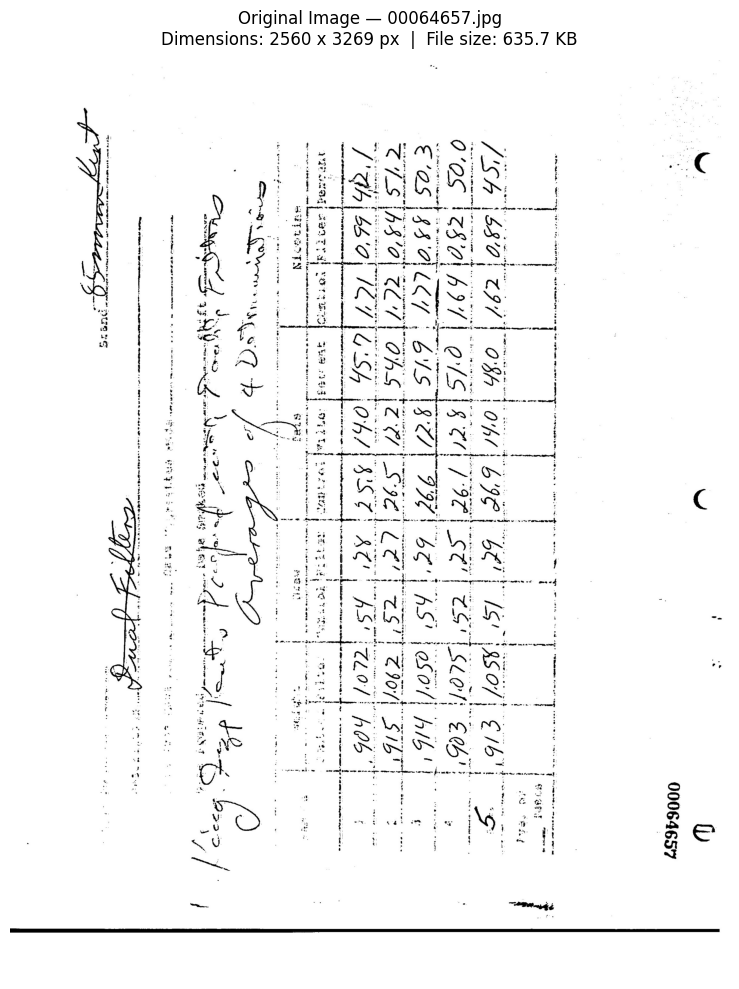

Displayed: 00064657.jpg


In [ ]:
# OpenCV stores images in BGR format, not the RGB format used by most other libraries including Matplotlib
# Matplotlib expect RGB order 
# BGR => Blue Green Red & RGB => Red Green Blue
# Reference: https://www.geeksforgeeks.org/python-opencv-cv2-cvtcolor-method/

sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# Create the figure
plt.figure(figsize=(14, 10))

# Display the image
# cmap=None uses colour (default) set cmap='gray' for greyscale
plt.imshow(sample_img_rgb)

# Remove axis ticks. 
# This is not useful for document images
plt.axis('off')

# Add a title showing the filename and dimensions
# Reference: https://www.w3schools.com/python/matplotlib_labels.asp
plt.title(
    f"Original Image — {image_files[SAMPLE_INDEX]}\n"
    f"Dimensions: {width} x {height} px  |  File size: {file_size_kb:.1f} KB",
    fontsize=12,
    pad=12
)

#Reference: https://www.geeksforgeeks.org/python/matplotlib-pyplot-tight_layout-in-python/
plt.tight_layout()
plt.show()

print(f"Displayed: {image_files[SAMPLE_INDEX]}")